In [80]:
import duckdb
import pandas as pd
import seaborn as sns

In [81]:
con = duckdb.connect("/home/etienne/projects/inatML/data/raw/raw.duckdb")
df = con.execute("SELECT * FROM downloads").df()
con.close()

In [82]:
print_obs = lambda df: print( "Total observations:", df['obs_count'].sum())


In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 368303 entries, 0 to 368302
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   id                             368303 non-null  int64         
 1   uuid                           368303 non-null  str           
 2   observed_on_string             367590 non-null  str           
 3   observed_on                    367588 non-null  datetime64[us]
 4   time_observed_at               363722 non-null  str           
 5   time_zone                      368287 non-null  str           
 6   user_id                        368303 non-null  int64         
 7   created_at                     368303 non-null  str           
 8   updated_at                     368303 non-null  str           
 9   quality_grade                  368303 non-null  str           
 10  license                        290979 non-null  str           
 11  url        

In [84]:
raw_count = df.shape[0]
df = df[df['observed_on'] >= '2000-01-01']
print('Removing outliers before 2000 -> Removed', raw_count - df.shape[0], 'observations')


Removing outliers before 2000 -> Removed 1151 observations


In [85]:
#Observation count filter

threshold = 100

unique_users =  df['user_id'].nunique()
df_user = df.groupby(by ='user_id').count().reset_index('user_id')
df_user = df_user[['user_id', 'id']].rename(columns={'id': 'obs_count'})
df_user.sort_values(by='obs_count', inplace=True, ascending= False)
df_user = df_user[df_user['obs_count'] >= threshold]

print("Unique users:", unique_users)
print("Unique users with over 20:", df_user.shape[0])
print_obs(df_user)

Unique users: 21438
Unique users with over 20: 464
Total observations: 202115


In [ ]:
#Temporal filter
old_threshold = '2018-01-01'
new_threshold = '2024-01-01'
df_temporal = pd.merge(df, df_user, on=['user_id'], how='inner')
df_temporal

min = df_temporal[['user_id', 'observed_on']].groupby(by='user_id').min().reset_index('user_id').rename(columns={'observed_on' : 'oldest'})
max = df_temporal[['user_id', 'observed_on']].groupby(by='user_id').max().reset_index('user_id').rename(columns={'observed_on' : 'newest'})
df_user = pd. merge(df_user, min, on=['user_id'], how='inner')
df_user = pd. merge(df_user, max, on=['user_id'], how='inner')


df_user = df_user[df_user['oldest'] <= old_threshold]
print("User with obs older than 2018: ", df_user.shape[0])
print_obs(df_user)

df_user = df_user[df_user['newest'] >= new_threshold]
print("User with last obs at least in last 2 years: ", df_user.shape[0])
print_obs(df_user)

df_user


User with obs older than 2018:  93
Total observations: 76839
User with last obs at least in last 2 years:  84
Total observations: 75167


,user_id,obs_count,oldest,newest
0,170921,13697,2007-05-08,2026-02-13
1,2129201,9187,2016-06-14,2025-11-02
2,696204,6882,2004-09-26,2026-02-28
5,2463161,4627,2005-03-12,2026-02-26
6,164015,4475,2011-06-05,2025-11-08
...,...,...,...,...
417,736005,114,2009-08-09,2026-02-28
421,550393,113,2017-06-03,2025-06-09
440,8073676,106,2011-04-15,2025-09-18
451,577059,103,2003-10-11,2026-02-16


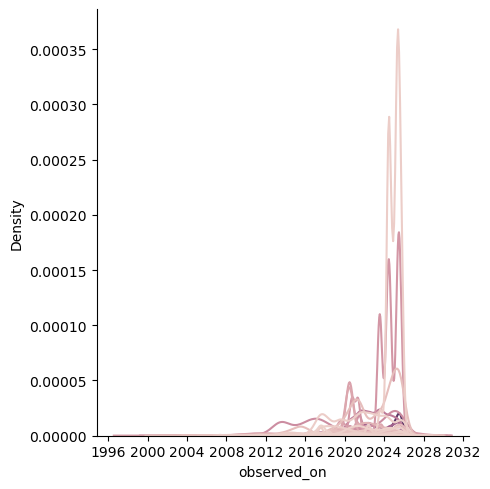

In [ ]:
df_plots = pd.merge(df, df_user, on=['user_id'], how='inner')
sns.displot(df_plots, x = 'observed_on', kind='kde', hue='user_id',legend=False)